In [ ]:
from fairnessinsight.Datasets.HeartDataset import HeartDataset
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [4]:
h = HeartDataset()
h.num_repetitions = 1
h.execute_models()

({'LogisticRegression': 80.328,
  'DecisionTreeClassifier': 72.131,
  'RandomForestClassifier': 81.967},
 {'LogisticRegression': 82.353,
  'DecisionTreeClassifier': 71.186,
  'RandomForestClassifier': 83.077})

In [5]:
features = h.dataset.columns.drop(h.predicted_attr)
df = h.dataset
features

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [6]:
x = df.loc[:, features].values

y = df.loc[:,['target']].values

len(x), len(y)

(302, 302)

In [7]:
x = StandardScaler().fit_transform(x)

pca = PCA(n_components=2)

principalComponents = pca.fit_transform(x)

principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])

finalDf = pd.concat([principalDf, df[h.predicted_attr]], axis=1)


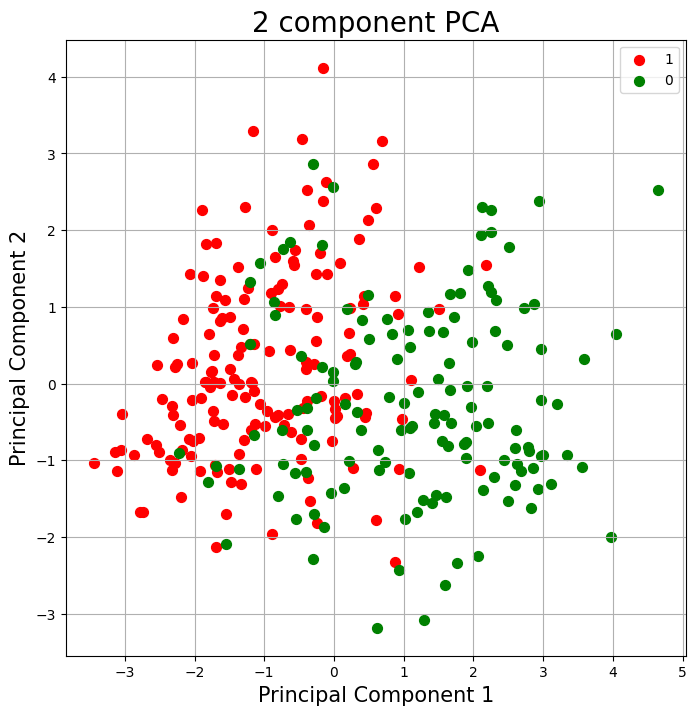

In [8]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)

targets = df[h.predicted_attr].unique()
colors = ['r', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf[h.predicted_attr] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

In [33]:
pca.explained_variance_ratio_

array([0.21313479, 0.11859478])

In [27]:
# Display loadings as a DataFrame for better readability
import pandas as pd
loadings = pca.components_
loadings_df = pd.DataFrame(
    loadings,
    columns=df.columns.drop('target'),  # Assuming `data` is a DataFrame with feature names
    index=[f"PC{i+1}" for i in range(len(loadings))]
)
print(loadings_df)

loadings_pc1 = loadings_df.iloc[0]
loadings_pc2 = loadings_df.iloc[1]

          age       sex        cp  trestbps      chol       fbs   restecg  \
PC1  0.313267  0.093922 -0.272530  0.184876  0.113827  0.074016 -0.125403   
PC2  0.407848 -0.371002  0.298938  0.437181  0.362194  0.318404 -0.218611   

      thalach     exang   oldpeak     slope        ca     thal  
PC1 -0.414481  0.358532  0.417687 -0.376377  0.291653  0.22115  
PC2  0.080825 -0.266081 -0.055946  0.055267  0.111171 -0.19823  


In [ ]:
loadings_pc1 = loadings_df.iloc[0]
loadings_pc2 = loadings_df.iloc[1]

# sort the loadings_pc1 and loadings_pc2
loadings_pc1 = loadings_pc1.sort_values(ascending=False)
loadings_pc2 = loadings_pc2.sort_values(ascending=False)

Text(0.5, 0, 'Feature')

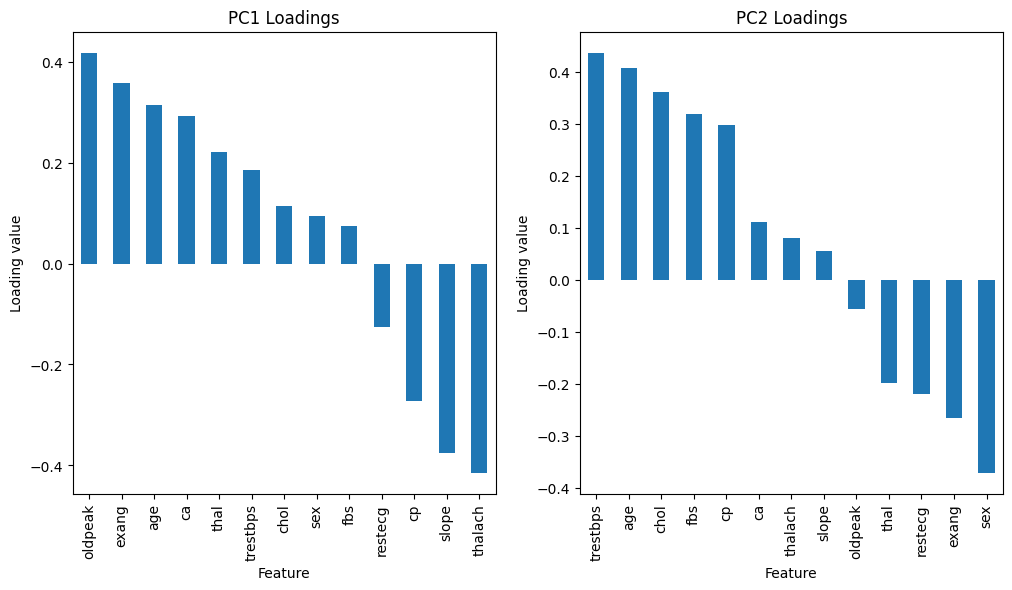

In [30]:
# create a two plots side by side for PC1 and PC2
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

loadings_pc1.plot(kind='bar', ax=axs[0])
axs[0].set_title('PC1 Loadings')
axs[0].set_ylabel('Loading value')
axs[0].set_xlabel('Feature')

loadings_pc2.plot(kind='bar', ax=axs[1])
axs[1].set_title('PC2 Loadings')
axs[1].set_ylabel('Loading value')
axs[1].set_xlabel('Feature')